In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

In [2]:
IMAGE_SIZE = 16

composed = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()])

In [3]:
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=composed)

In [4]:
validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=composed)

In [5]:
type(train_dataset[0][1])

int

In [6]:
train_dataset[3][1]

1

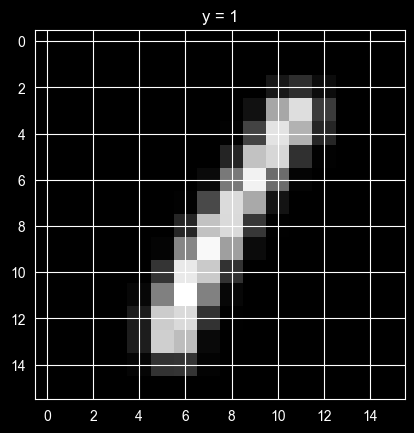

In [7]:
show_data(train_dataset[3])

### Modeling

In [8]:
class CNN(nn.Module):

    # Contructor
    def __init__(self, out_1=16, out_2=32):
        super(CNN, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, 10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


In [9]:
class CNN_batch(nn.Module):

    # Contructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN_batch, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.conv1_bn = nn.BatchNorm2d(out_1)

        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.conv2_bn = nn.BatchNorm2d(out_2)

        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
        self.bn_fc1 = nn.BatchNorm1d(10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x=self.conv1_bn(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x=self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x=self.bn_fc1(x)
        return x

In [21]:
model = CNN(out_1=16, out_2=32)
model_batch=CNN_batch(out_1=16, out_2=32)

#### Use GPU

In [22]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)
model_batch.to(device)

CNN_batch(
  (cnn1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv1_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=10, bias=True)
  (bn_fc1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [33]:
def train_model(model,train_loader,validation_loader,optimizer,n_epochs=4):

    #global variable
    N_test=len(validation_dataset)
    accuracy_list=[]
    loss_list=[]
    for epoch in range(n_epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            model.train()
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            loss_list.append(loss.item())

        correct=0
        #perform a prediction on the validation  data
        with torch.no_grad():
            for x_test, y_test in validation_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                model.eval()
                z = model(x_test)
                _, yhat = torch.max(z.data, 1)
                correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        accuracy_list.append(accuracy)

    return accuracy_list, loss_list

```python
# 错误写法（会累积计算图）
loss_list.append(loss.data)

# 正确写法（只存数字，释放显存）
loss_list.append(loss.item())
```


一定要坚持使用 `.item()` 提取数值，把计算图留在 GPU 里消耗掉。


### 1. 为什么 `loss.data`（或者直接存 `loss`）很危险？

当你在进行 `loss = criterion(z, y)` 时，`loss` 不仅仅是一个数字，它是一个**带有“历史包袱”的张量**。

- 这个“包袱”就是**计算图（Computational Graph）**。它记录了数据是怎么从输入经过每一层卷积、ReLU 到达输出的。

- 只有保留这个图，PyTorch 才能执行 `loss.backward()` 来计算梯度。

- **如果你直接把 `loss` 或 `loss.data` 存进列表**，PyTorch 会认为你以后还要用到这个计算图，于是它会**强制把整个网络在这一轮迭代中产生的中间变量全部留在显存里**，不准释放。


随着循环运行，每一个 Epoch 都会往列表里塞进一个新的、庞大的计算图。很快，你 M1 Pro 的统一内存就会被塞满。


### 2. 为什么 `.item()` 是安全的？

当你调用 **`loss.item()`** 时：

- 它会把 Tensor 里的那个数字提取出来，变成一个普通的 **Python Float**。

- 这个 Float 是**不带计算图**的。

- 一旦你只存数字，PyTorch 就会意识到：“哦，这一轮的计算图没用了。” 于是它会在下一次迭代开始前，自动把 GPU 里的中间变量清空，释放空间。




In [30]:
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

In [31]:
accuracy_list_normal, loss_list_normal=train_model(model=model,n_epochs=10,train_loader=train_loader,validation_loader=validation_loader,optimizer=optimizer)

- 不使用GPU时，运行时间是2m35s
- 使用GPU时，运行时间 39s

In [32]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model_batch.parameters(), lr = learning_rate)
accuracy_list_batch, loss_list_batch=train_model(model=model_batch,n_epochs=10,train_loader=train_loader,validation_loader=validation_loader,optimizer=optimizer)

- 不使用GPU时，运行时间是2m49s
- 使用GPU 运行时间53s

### Evaluation

NameError: name 'loss_list_batch' is not defined

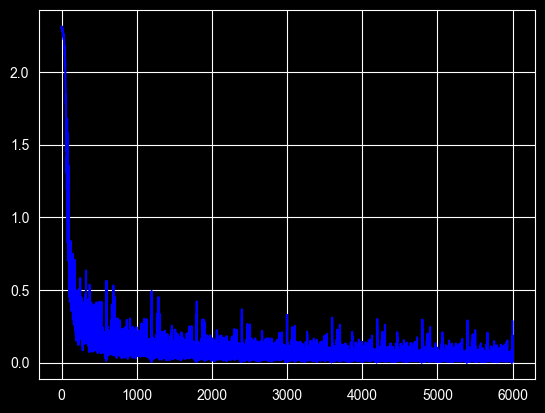

In [18]:
plt.plot(loss_list_normal, 'b',label='loss normal cnn ')
plt.plot(loss_list_batch,'r',label='loss batch cnn')
plt.xlabel('iteration')
plt.title("loss")
plt.legend()

In [ ]:
plt.plot(accuracy_list_normal, 'b',label=' normal CNN')
plt.plot(accuracy_list_batch,'r',label=' CNN with Batch Norm')
plt.xlabel('Epoch')
plt.title("Accuracy ")
plt.legend()
plt.show()